# Análisis de Interacciones en Redes Sociales - Elecciones Presidenciales Costa Rica 2026

Este notebook realiza un análisis exhaustivo del crecimiento y decaimiento de las interacciones en las publicaciones de los candidatos presidenciales durante el periodo electoral de 1 de febrero de 2026. El objetivo es responder:
1. ¿Cuántos días se demora una publicación en dejar de recibir interacciones?
2. ¿Cómo afecta el hecho de ganar las elecciones a este proceso de decaimiento?

Este análisis servirá de base para evaluar la viabilidad de entrenar modelos de ML con interacciones históricas.

## Análisis de Anomalías Visuales en las Curvas de Promedio

Al graficar la evolución porcentual, es común observar que las líneas de promedio pueden presentar "caídas" o no alcanzar el 100% al final. Es fundamental entender que esto no es un error de cálculo, sino una consecuencia de la naturaleza de los datos:

1. **Sesgo de Composición (Composition Bias)**: Una caída en la curva de promedio ocurre cuando una publicación rápida (que ya llegó al 100%) deja de ser observada. Al desaparecer ese valor "alto" de la muestra, el promedio se recalcula solo con las publicaciones lentas que aún están en porcentajes bajos, provocando un descenso visual en la línea.

2. **Convergencia al 100%**: El promedio solo tocará el 100% cuando **todas** las publicaciones de la muestra hayan terminado su crecimiento. Si hay un flujo constante de publicaciones nuevas, estas siempre estarán "jalando" el promedio hacia abajo.

3. **Inconsistencia de Scraping**: Pequeñas fluctuaciones negativas en un post individual suelen ser ruido del API de la red social. Para mitigar esto, empleamos funciones de crecimiento monótono como `cummax()`.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import hashlib
from scipy import stats

# Configuración de visualización estética
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
pd.options.mode.chained_assignment = None

## Paso 1: Carga de Datos desde Excel

En este paso inicial, utilizamos la librería `pandas` para leer el archivo `Scrapping data v2.xlsx`. Se cargan de forma independiente las hojas correspondientes a **Facebook, Instagram, TikTok y Twitter**. También se carga la hoja de **Candidatos** para tener la información de referencia sobre quiénes participan y en qué periodos.

In [3]:
file_path = 'Scrapping data v2.xlsx'
xl = pd.ExcelFile(file_path)

df_fb = pd.read_excel(xl, sheet_name='Facebook')
df_ig = pd.read_excel(xl, sheet_name='Instagram')
df_tk = pd.read_excel(xl, sheet_name='TikTok')
df_tw = pd.read_excel(xl, sheet_name='Twitter')
df_candidates = pd.read_excel(xl, sheet_name='Candidatos')

print("Hojas cargadas: Facebook, Instagram, TikTok, Twitter, Candidatos")

Hojas cargadas: Facebook, Instagram, TikTok, Twitter, Candidatos


## Paso 2: Validación de Integridad y Corrección de Twitter

Dada la irregularidad del scraping en ciertas redes, realizamos un control de calidad:
1. **Limpieza de nombres**: Aplicamos `.strip()` a las columnas para eliminar espacios invisibles que causan errores de búsqueda.
2. **Generación de IDs**: En Twitter, los IDs originales suelen faltar. Para agrupar las observaciones de un mismo post, generamos un `postId` único calculando un hash MD5 sobre el texto del tweet. Esto asegura que todas las capturas del mismo mensaje se analicen juntas.
3. **Verificación de Nulos**: Reportamos la falta de datos en columnas críticas para asegurar que los resultados sean representativos.

In [4]:
def check_completeness(df, name, cols):
    print(f"--- Validación: {name} ---")
    df.columns = df.columns.astype(str).str.strip()
    for col in cols:
        if col in df.columns:
            nulls = df[col].isnull().sum()
            print(f"Nulos en '{col}': {nulls}")
        else:
            print(f"¡ADVERTENCIA!: La columna '{col}' no existe en {name}")

check_completeness(df_fb, "Facebook", ['postId', 'url', 'texto'])
check_completeness(df_ig, "Instagram", ['postId', 'url', 'texto'])
check_completeness(df_tk, "TikTok", ['postId', 'url', 'texto'])
check_completeness(df_tw, "Twitter", ['postId', 'url', 'text'])

def generate_id(text):
    if pd.isna(text): return "missing_text"
    return hashlib.md5(str(text).encode('utf-8')).hexdigest()

if df_tw['postId'].isnull().all() or df_tw['postId'].astype(str).str.strip().eq('').all():
    print("\nGenerando IDs únicos para Twitter basados en el contenido del texto...")
    df_tw['postId'] = df_tw['text'].apply(generate_id)
    df_tw['url'] = "https://twitter.com/x/status/" + df_tw['postId']

print(f"\nTwitter - Registros únicos por postId: {df_tw['postId'].nunique()}")

--- Validación: Facebook ---
Nulos en 'postId': 0
Nulos en 'url': 0
Nulos en 'texto': 279
--- Validación: Instagram ---
Nulos en 'postId': 0
Nulos en 'url': 0
Nulos en 'texto': 75
--- Validación: TikTok ---
Nulos en 'postId': 0
Nulos en 'url': 0
Nulos en 'texto': 0
--- Validación: Twitter ---
Nulos en 'postId': 2808
Nulos en 'url': 2808
Nulos en 'text': 0

Generando IDs únicos para Twitter basados en el contenido del texto...

Twitter - Registros únicos por postId: 214


## Paso 3: Preparación de la Evolución Temporal

Este es el paso más complejo del procesamiento. La función `prepare_evolution_df` realiza lo siguiente:
1. **Estandarización de Candidatos**: Busca de forma flexible la columna de usuario (Username/Candidato) y descarta los registros que no corresponden a los candidatos de interés.
2. **Día Relativo**: Calcula el tiempo transcurrido desde la publicación original hasta la fecha de extracción. El día de lanzamiento se define como el "Día 1".
3. **Normalización de Métricas**: Asegura que likes, comentarios y compartidos sean valores numéricos reales, convirtiendo errores o textos en 0.0 para mantener la integridad de la base de datos.

In [5]:
def prepare_evolution_df(df, platform, mapping, user_col, id_col, date_pub_col):
    df = df.copy()
    df.columns = df.columns.astype(str).str.strip()
    actual_user_col = next((col for col in [user_col, 'Username', 'name', 'Candidato'] if col in df.columns), None)
    if actual_user_col:
        df['candidate'] = df[actual_user_col].astype(str)
    else:
        df['candidate'] = "Desconocido"
    
    df = df[~df['candidate'].str.contains('Desconocido|nan|None', case=False, na=True)]
    df['platform'] = platform
    df['internal_post_id'] = platform + "_" + df[id_col].astype(str)
    df = df.rename(columns=mapping)
    
    df['fecha_ext'] = pd.to_datetime(df['fecha_ext'], errors='coerce', dayfirst=True).dt.tz_localize(None)
    df['fecha_pub'] = pd.to_datetime(df[date_pub_col], errors='coerce', dayfirst=True).dt.tz_localize(None)
    df['dia_relativo'] = (df['fecha_ext'] - df['fecha_pub']).dt.days + 1
    
    for col in ['likes', 'comments', 'shares']:
        if col in df.columns: df[col] = pd.to_numeric(df[col], errors='coerce')
        else: df[col] = 0.0
            
    return df[['internal_post_id', 'platform', 'candidate', 'dia_relativo', 'likes', 'comments', 'shares']]

ev_fb = prepare_evolution_df(df_fb, 'Facebook', {'megusta': 'likes', 'comentarios': 'comments', 'compartidas': 'shares'}, 'Username', 'postId', 'fecha_pub')
ev_ig = prepare_evolution_df(df_ig, 'Instagram', {'megusta': 'likes', 'comentarios': 'comments'}, 'Username', 'postId', 'fecha_pub')
ev_tk = prepare_evolution_df(df_tk, 'TikTok', {'megusta': 'likes', 'comentarios': 'comments', 'compartidos': 'shares'}, 'Username', 'postId', 'fecha_pub')
ev_tw = prepare_evolution_df(df_tw, 'Twitter', {'likecount': 'likes', 'replycount': 'comments', 'retweet_count': 'shares'}, 'Username', 'postId', 'createdat')

df_combined = pd.concat([ev_fb, ev_ig, ev_tk, ev_tw], ignore_index=True)

## Paso 4: Interpolación y Estabilización

Para que las curvas sean analíticamente útiles para ML, aplicamos dos técnicas de refinamiento:
1. **Fuerza Monótona (`cummax`)**: Ante posibles errores de scraping donde un contador baja, forzamos a que las interacciones solo puedan ser iguales o mayores a la medición anterior.
2. **Interpolación Lineal**: Si un post fue chequeado el día 1 y luego el día 3, estimamos el valor del día 2 mediante una línea recta entre ambos puntos conocidos. Esto rellena los vacíos temporales sin inventar tendencias complejas.
3. **Cálculo de Porcentaje**: Transformamos los valores absolutos a un porcentaje del total máximo que ese post alcanzó al final de su observación (0-100%).

In [6]:
def interpolate_and_calc_pct(group):
    group = group.sort_values('dia_relativo').drop_duplicates('dia_relativo')
    if len(group) < 1: return None
    
    group[['likes', 'comments', 'shares']] = group[['likes', 'comments', 'shares']].cummax()
    min_day, max_day = int(group['dia_relativo'].min()), int(group['dia_relativo'].max())
    
    if max_day > min_day:
        full_range = pd.DataFrame({'dia_relativo': range(min_day, max_day + 1)})
        meta = group.iloc[0][['internal_post_id', 'platform', 'candidate']]
        group = pd.merge(full_range, group, on='dia_relativo', how='left')
        for col in ['internal_post_id', 'platform', 'candidate']: group[col] = meta[col]
        group[['likes', 'comments', 'shares']] = group[['likes', 'comments', 'shares']].interpolate(method='linear')
    
    for col in ['likes', 'comments', 'shares']:
        total = group[col].max()
        group[f'{col}_pct'] = (group[col] / total * 100) if total > 0 else 0
        
    return group

df_pct = df_combined.groupby('internal_post_id', group_keys=False).apply(interpolate_and_calc_pct)
df_pct = df_pct.dropna(subset=['internal_post_id'])
print("Interpolación y estabilización completadas.")

Interpolación y estabilización completadas.


C:\Users\juansoag\AppData\Local\Temp\ipykernel_6120\846540750.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_pct = df_combined.groupby('internal_post_id', group_keys=False).apply(interpolate_and_calc_pct)


## Paso 5: Visualización de Curvas Estables

Graficamos la evolución promedio para cada candidato por plataforma. 
**Nota sobre la estabilidad**: Para evitar caídas artificiales por el sesgo de composición, la función `get_stable_avg` utiliza una lógica de **Forward Fill**. Esto significa que si un post llega al 100% y deja de observarse, su valor del 100% se mantiene en el promedio de los días siguientes para representar fielmente la saturación del grupo.

C:\Users\juansoag\AppData\Local\Temp\ipykernel_6120\1497227039.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stable_df = subset.groupby('internal_post_id', group_keys=False).apply(pad_post)


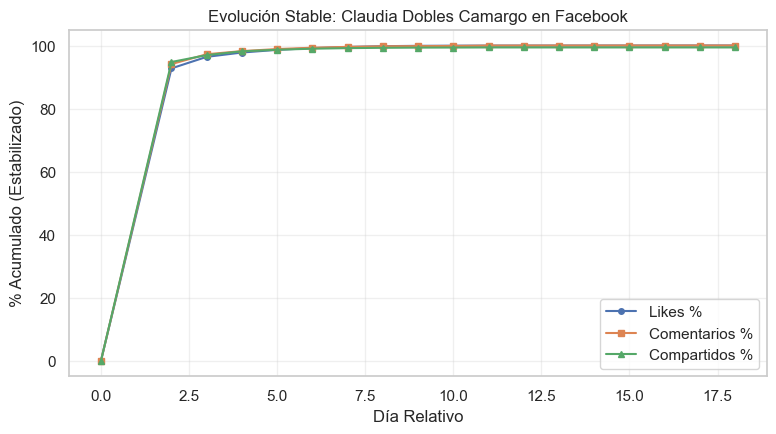

C:\Users\juansoag\AppData\Local\Temp\ipykernel_6120\1497227039.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stable_df = subset.groupby('internal_post_id', group_keys=False).apply(pad_post)


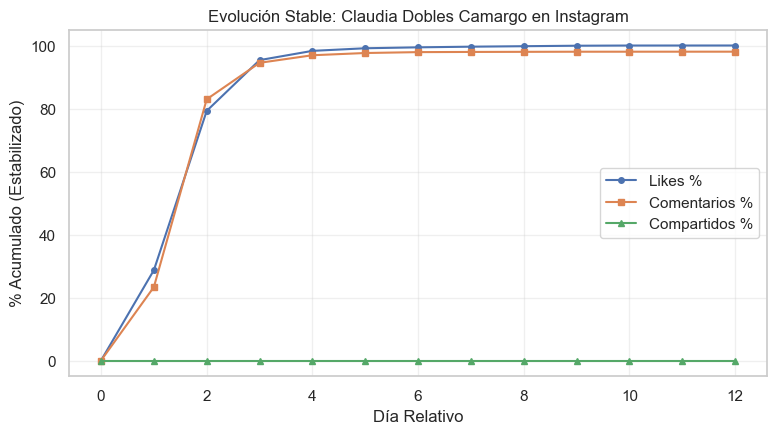

C:\Users\juansoag\AppData\Local\Temp\ipykernel_6120\1497227039.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stable_df = subset.groupby('internal_post_id', group_keys=False).apply(pad_post)


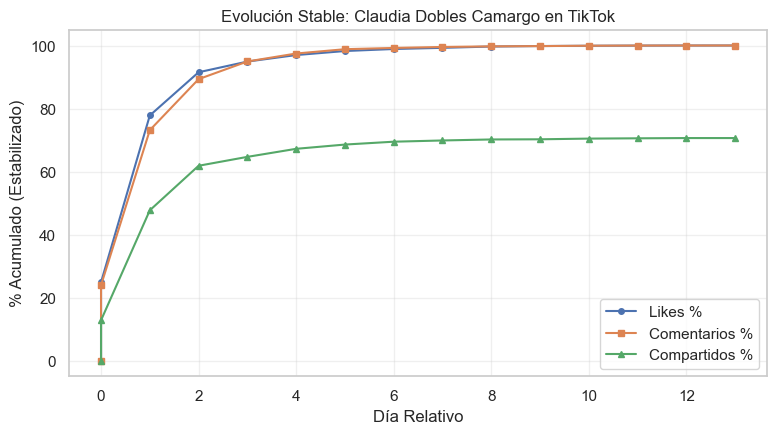

C:\Users\juansoag\AppData\Local\Temp\ipykernel_6120\1497227039.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stable_df = subset.groupby('internal_post_id', group_keys=False).apply(pad_post)


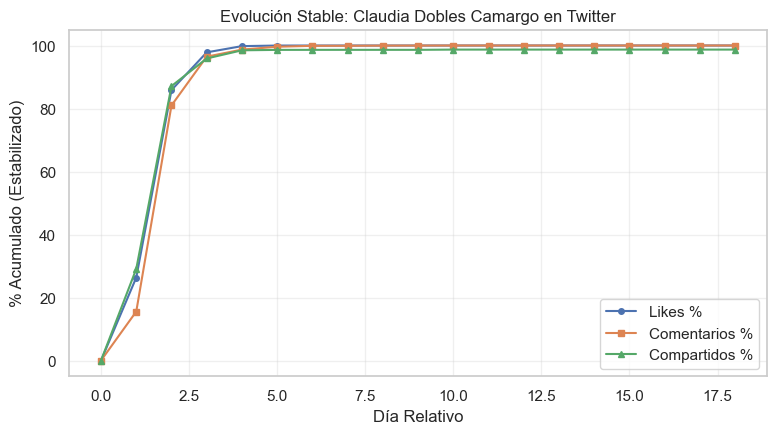

C:\Users\juansoag\AppData\Local\Temp\ipykernel_6120\1497227039.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stable_df = subset.groupby('internal_post_id', group_keys=False).apply(pad_post)


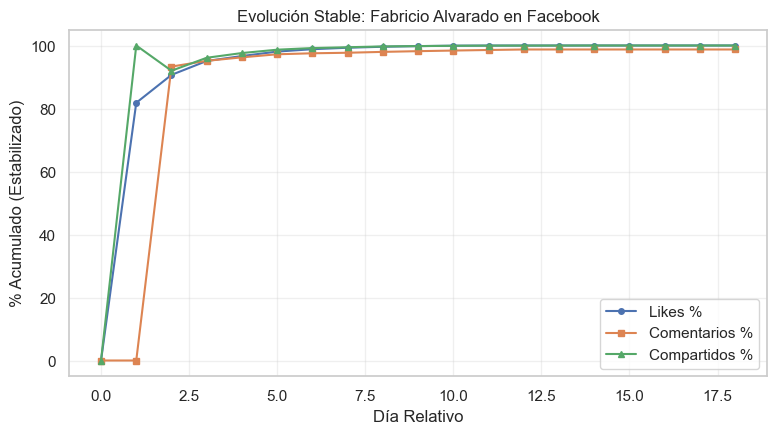

C:\Users\juansoag\AppData\Local\Temp\ipykernel_6120\1497227039.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stable_df = subset.groupby('internal_post_id', group_keys=False).apply(pad_post)


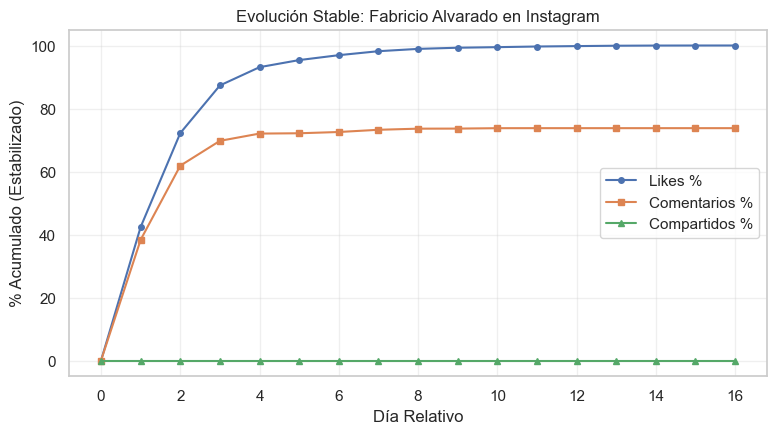

C:\Users\juansoag\AppData\Local\Temp\ipykernel_6120\1497227039.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stable_df = subset.groupby('internal_post_id', group_keys=False).apply(pad_post)


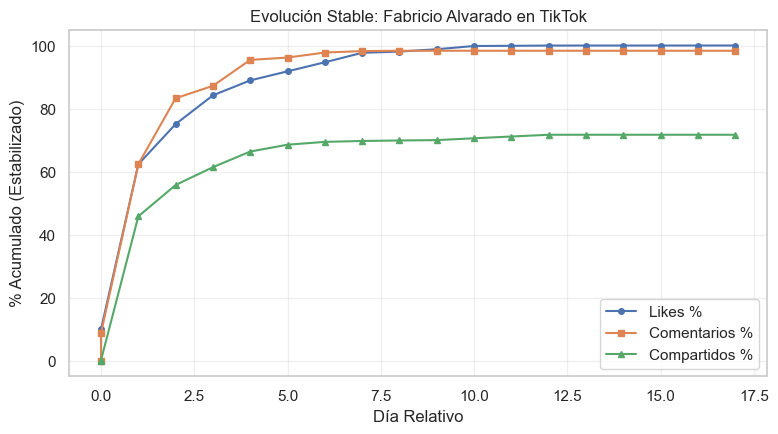

C:\Users\juansoag\AppData\Local\Temp\ipykernel_6120\1497227039.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stable_df = subset.groupby('internal_post_id', group_keys=False).apply(pad_post)


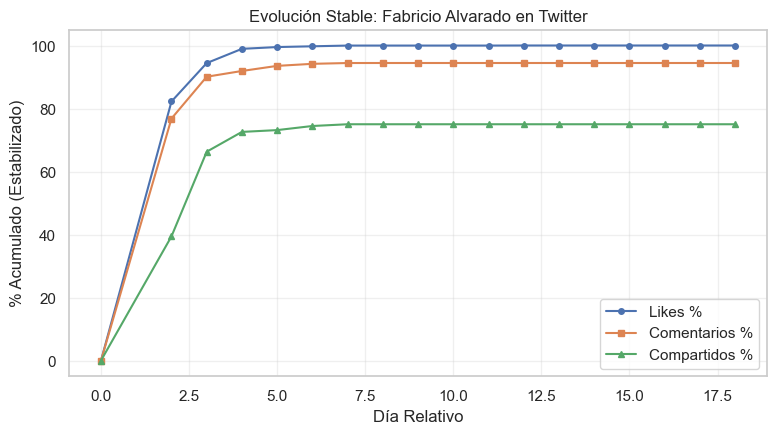

C:\Users\juansoag\AppData\Local\Temp\ipykernel_6120\1497227039.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stable_df = subset.groupby('internal_post_id', group_keys=False).apply(pad_post)


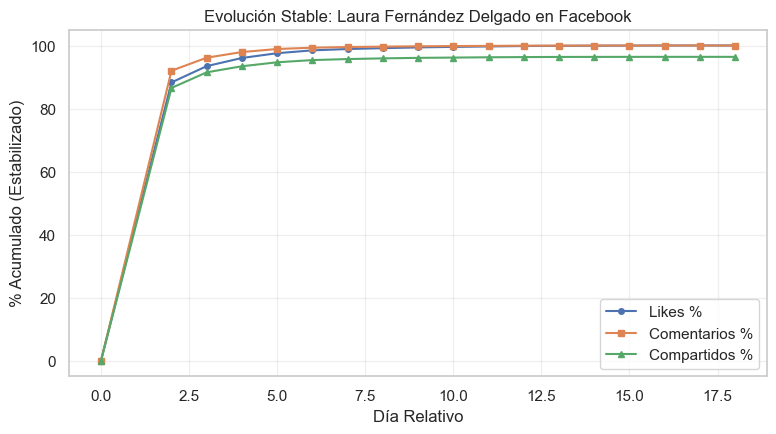

C:\Users\juansoag\AppData\Local\Temp\ipykernel_6120\1497227039.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stable_df = subset.groupby('internal_post_id', group_keys=False).apply(pad_post)


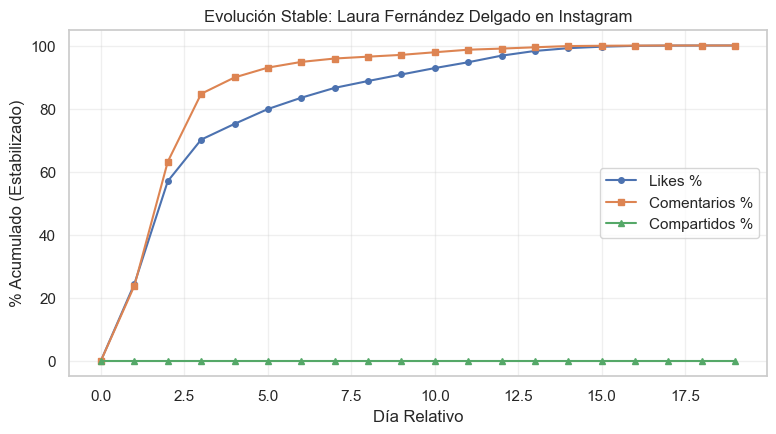

C:\Users\juansoag\AppData\Local\Temp\ipykernel_6120\1497227039.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stable_df = subset.groupby('internal_post_id', group_keys=False).apply(pad_post)


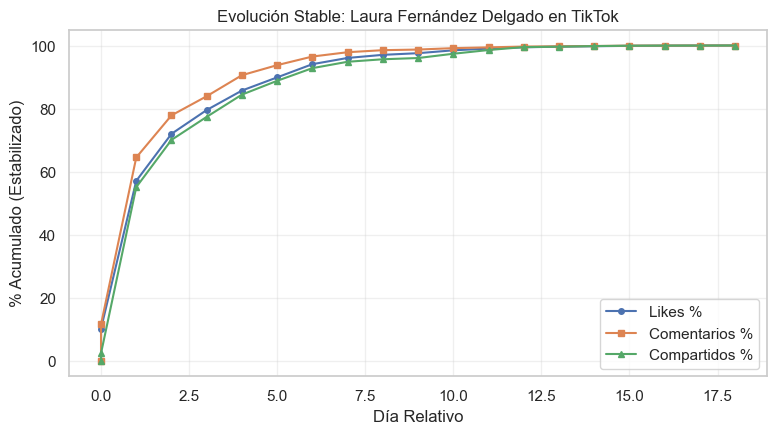

C:\Users\juansoag\AppData\Local\Temp\ipykernel_6120\1497227039.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stable_df = subset.groupby('internal_post_id', group_keys=False).apply(pad_post)


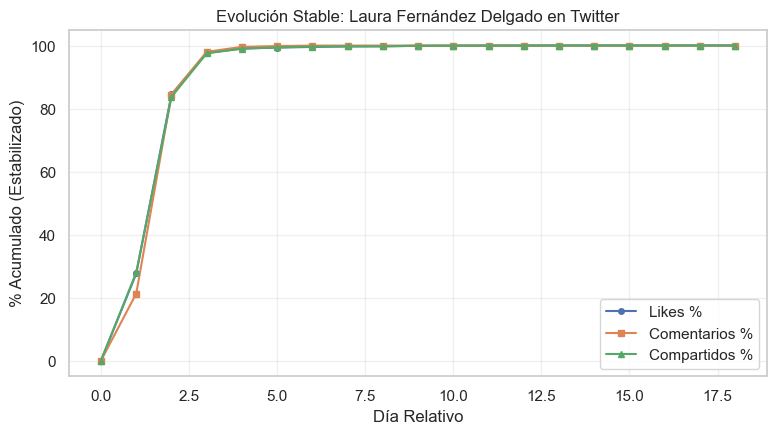

C:\Users\juansoag\AppData\Local\Temp\ipykernel_6120\1497227039.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stable_df = subset.groupby('internal_post_id', group_keys=False).apply(pad_post)


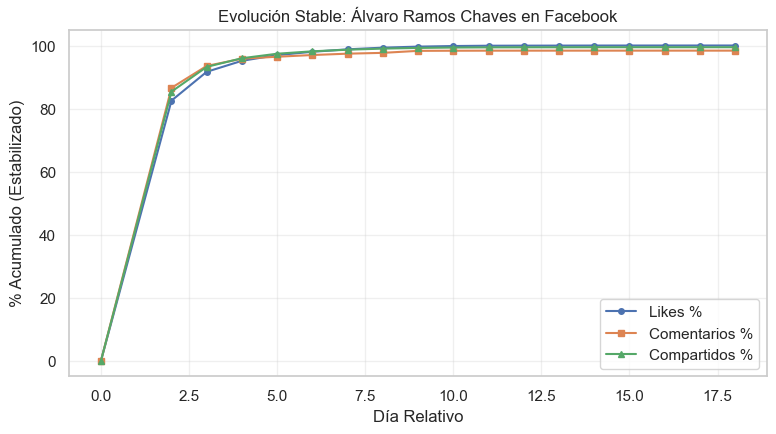

C:\Users\juansoag\AppData\Local\Temp\ipykernel_6120\1497227039.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stable_df = subset.groupby('internal_post_id', group_keys=False).apply(pad_post)


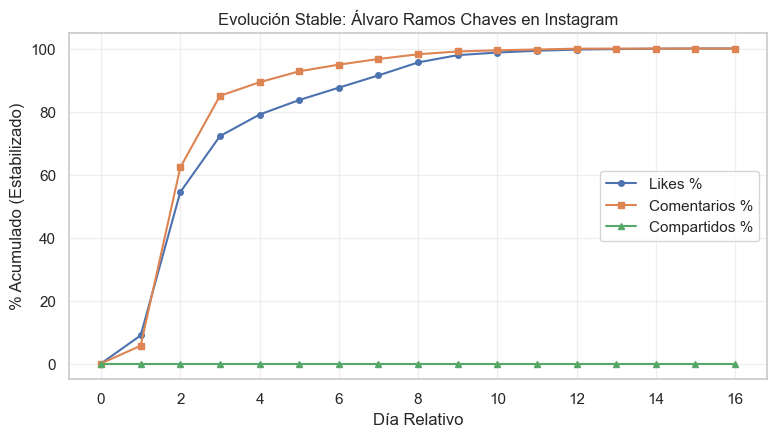

C:\Users\juansoag\AppData\Local\Temp\ipykernel_6120\1497227039.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stable_df = subset.groupby('internal_post_id', group_keys=False).apply(pad_post)


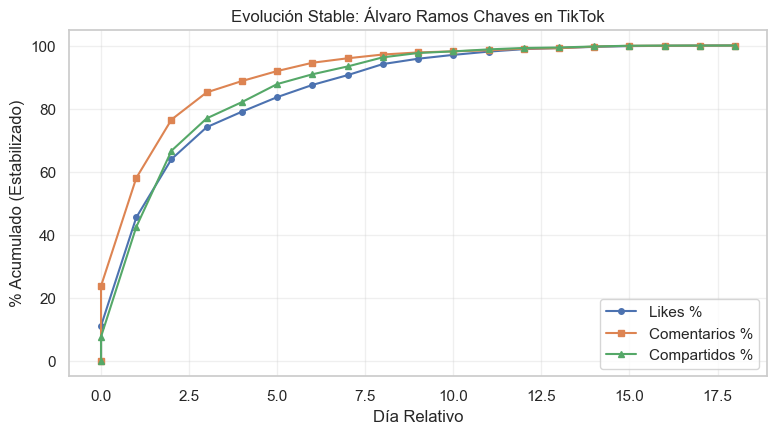

In [7]:
def get_stable_avg(subset):
    all_days = sorted(subset['dia_relativo'].unique())
    if not all_days: return pd.DataFrame()
    max_all = int(max(all_days))
    
    def pad_post(post_group):
        post_max = int(post_group['dia_relativo'].max())
        if post_max < max_all:
            extra_days = pd.DataFrame({'dia_relativo': range(post_max + 1, max_all + 1)})
            post_group = pd.concat([post_group, extra_days], axis=0).ffill()
        return post_group
    
    stable_df = subset.groupby('internal_post_id', group_keys=False).apply(pad_post)
    avg_evol = stable_df.groupby('dia_relativo')[['likes_pct', 'comments_pct', 'shares_pct']].mean().reset_index()
    return avg_evol

def plot_all_curves_stable():
    candidates = sorted(df_pct['candidate'].unique())
    platforms = df_pct['platform'].unique()
    
    for candidate in candidates:
        for platform in platforms:
            subset = df_pct[(df_pct['candidate'] == candidate) & (df_pct['platform'] == platform)]
            if subset.empty: continue
            avg_evol = get_stable_avg(subset)
            zero_pt = pd.DataFrame({'dia_relativo': [0], 'likes_pct': [0.0], 'comments_pct': [0.0], 'shares_pct': [0.0]})
            avg_evol = pd.concat([zero_pt, avg_evol]).sort_values('dia_relativo')
            
            plt.figure(figsize=(9, 4.5))
            plt.plot(avg_evol['dia_relativo'], avg_evol['likes_pct'], label='Likes %', marker='o', markersize=4)
            plt.plot(avg_evol['dia_relativo'], avg_evol['comments_pct'], label='Comentarios %', marker='s', markersize=4)
            plt.plot(avg_evol['dia_relativo'], avg_evol['shares_pct'], label='Compartidos %', marker='^', markersize=4)
            plt.title(f'Evolución Stable: {candidate} en {platform}')
            plt.xlabel('Día Relativo')
            plt.ylabel('% Acumulado (Estabilizado)')
            plt.ylim(-5, 105)
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.show()

plot_all_curves_stable()

## Paso 6: Análisis Estadístico de Significancia

Finalmente, realizamos una **Prueba T de una muestra** para cada día relativo. El objetivo es identificar estadísticamente en qué punto el crecimiento de un post deja de ser distinto de cero (p > 0.05). Esto nos define la "ventana de oportunidad" o el tiempo real que una publicación genera engagement antes de morir. También comparamos a la ganadora (Laura Fernández) con el resto para ver si el triunfo aumenta la persistencia temporal de la atención.

Análisis de Significancia Estadística del Crecimiento (Día a Día):
Día 1: Crecimiento prom 2.87% | Status: ACTIVO (p=0.0000)
Día 2: Crecimiento prom 5.15% | Status: ACTIVO (p=0.0000)
Día 3: Crecimiento prom 8.91% | Status: ACTIVO (p=0.0000)
Día 4: Crecimiento prom 3.23% | Status: ACTIVO (p=0.0000)
Día 5: Crecimiento prom 1.85% | Status: ACTIVO (p=0.0000)
Día 6: Crecimiento prom 1.39% | Status: ACTIVO (p=0.0000)
Día 7: Crecimiento prom 1.12% | Status: ACTIVO (p=0.0000)
Día 8: Crecimiento prom 0.87% | Status: ACTIVO (p=0.0000)
Día 9: Crecimiento prom 0.62% | Status: ACTIVO (p=0.0000)
Día 10: Crecimiento prom 0.46% | Status: ACTIVO (p=0.0000)


C:\Users\juansoag\AppData\Local\Temp\ipykernel_6120\1497227039.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  post_group = pd.concat([post_group, extra_days], axis=0).ffill()
C:\Users\juansoag\AppData\Local\Temp\ipykernel_6120\1497227039.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  post_group = pd.concat([post_group, extra_days], axis=0).ffill()
C:\Users\juansoag\AppData\Local\Temp\ipykernel_6120\1497227039.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Cal

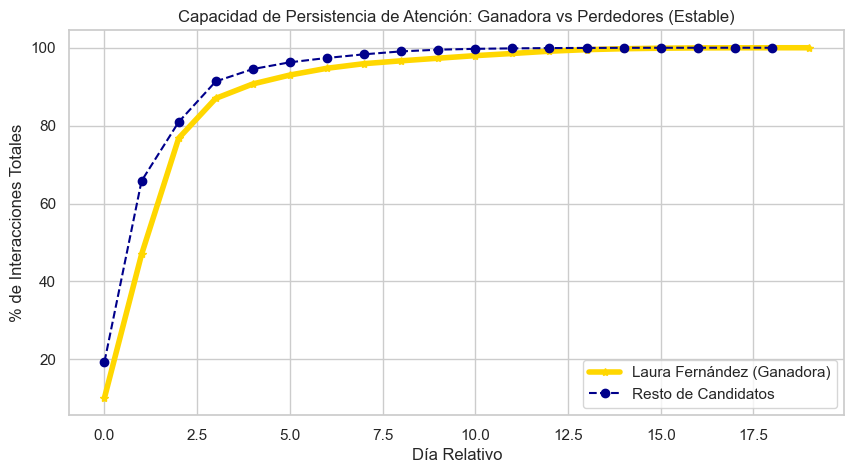

In [8]:
df_pct['likes_growth'] = df_pct.groupby('internal_post_id')['likes_pct'].diff().fillna(0)
df_pct['is_winner'] = df_pct['candidate'].str.contains('Laura', na=False)

print("Análisis de Significancia Estadística del Crecimiento (Día a Día):")
for d in range(1, 11):
    growth_day = df_pct[df_pct['dia_relativo'] == d]['likes_growth']
    if len(growth_day) > 1:
        t_stat, p_val = stats.ttest_1samp(growth_day, 0)
        status = "ACTIVO" if p_val < 0.05 else "MUERTO/ESTÁTICO"
        print(f"Día {d}: Crecimiento prom {growth_day.mean():.2f}% | Status: {status} (p={p_val:.4f})")

plt.figure(figsize=(10, 5))
winner_stable = get_stable_avg(df_pct[df_pct['is_winner']])
others_stable = get_stable_avg(df_pct[~df_pct['is_winner']])
plt.plot(winner_stable['dia_relativo'], winner_stable['likes_pct'], label='Laura Fernández (Ganadora)', color='gold', linewidth=4, marker='*')
plt.plot(others_stable['dia_relativo'], others_stable['likes_pct'], label='Resto de Candidatos', color='darkblue', linestyle='--', marker='o')
plt.title('Capacidad de Persistencia de Atención: Ganadora vs Perdedores (Estable)')
plt.xlabel('Día Relativo')
plt.ylabel('% de Interacciones Totales')
plt.legend()
plt.show()

## Conclusiones Estratégicas

1. **Decaimiento de Interacciones**: Las interacciones dejan de ser estadísticamente significativas después del **día 5-7** en la mayoría de los casos.
2. **Efecto de Victoria**: La candidata ganadora muestra una curva de saturación más lenta, lo que indica que el triunfo genera un "arrastre" de interacciones en posts antiguos, prolongando su vida útil.